# 2ai. ROI Comparison: Atlas-Based vs. Subject-Specific Habenula ROIs

Before comparing any BOLD/connectivity results, this notebook checks whether the atlas-based
habenula ROI and the manually-drawn, subject-specific habenula ROIs are actually describing
the same anatomy. For every participant, we compare their hand-drawn ROI against the single
group atlas-based ROI on two measures:

1. **Volume** - how many mm^3 does each ROI cover?
2. **Dice Similarity Coefficient (DSC)** - how much do the two ROIs spatially overlap, voxel-for-voxel?

This mirrors the anatomical-comparison step: quantify ROI differences across
the two methods *before* moving on to timeseries/connectivity comparisons.

In [1]:
import os
import os.path as op
import re
import glob

import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import image


## 1. Define Paths

`binary_rois_dir` holds one binarized, subject-specific habenula ROI (nifti) per participant.
`atlas_roi_path` is the single, group-level atlas-based habenula ROI (dilated by 2mm, per Methods)
that gets applied uniformly across all participants.

In [2]:
data_dir = "./dset"
deriv_dir = op.join(data_dir, "derivatives")

# Subject-specific (hand-drawn) binary ROIs - one file per participant
binary_rois_dir = op.join(data_dir, "seed-regions", "subj-spec-hbs", "binary_rois")

# Single group-level atlas-based ROI (dilated), applied to every participant
atlas_roi_path = op.join(data_dir, "seed-regions", "atlas-based-hb", "habenula_mni_dilated.nii.gz")

# Where to save the resulting comparison table
output_dir = op.join(deriv_dir, "roi-analysis")
os.makedirs(output_dir, exist_ok=True)
output_csv = op.join(output_dir, "roi_comparison_summary.csv")

# Subjects to exclude from this comparison.
# These 3 subjects are present in binary_rois/ but were NOT part of the group-drawn
# model table used in an earlier, confirmed version of the analysis
# (group-drawn-previous2/habenula/sub-group_task-rest_desc-1S2StTesthabenula_table.txt,
# N=1,479). Dropping them here brings this comparison back in line with that sample.
EXCLUDED_SUBJECTS = {"sub-0050361", "sub-0050731", "sub-0050363"}


## 2. Count How Many ROIs Will Be Analyzed

Sanity check *before* running anything: how many subject-specific ROI files are actually sitting
in `binary_rois_dir`? This should line up with your expected sample size (currently framed as
N=1,540 in the paper) - if it doesn't, better to catch that now than after the comparison runs.

In [3]:
# Find every subject-specific binary ROI file
roi_files_all = sorted(glob.glob(op.join(binary_rois_dir, "*.nii.gz")))

print(f"Found {len(roi_files_all)} subject-specific habenula ROIs in:\n  {binary_rois_dir}")

# Pull out subject IDs (e.g. 'sub-0050004') from each filename for a quick spot-check
sub_id_pattern = re.compile(r"(sub-\d+)")

def get_sub_id(f):
    return sub_id_pattern.search(op.basename(f)).group(1)

subject_ids_all = [get_sub_id(f) for f in roi_files_all]

print(f"\nFirst 5 subject IDs: {subject_ids_all[:5]}")
print(f"Last 5 subject IDs:  {subject_ids_all[-5:]}")

# Drop the known mismatched subjects (see EXCLUDED_SUBJECTS above) so this comparison
# matches the confirmed N=1,479 sample
roi_files = [f for f in roi_files_all if get_sub_id(f) not in EXCLUDED_SUBJECTS]
subject_ids = [get_sub_id(f) for f in roi_files]

print(f"\nExcluding {len(roi_files_all) - len(roi_files)} known mismatched subjects: {sorted(EXCLUDED_SUBJECTS)}")

# Optional cross-check against the participants list, if available, to flag any mismatch
participants_tsv = op.join(data_dir, "seed-regions", "subj-spec-hbs", "group-participants.tsv")
if op.exists(participants_tsv):
    participants_df = pd.read_csv(participants_tsv, sep="\t")
    n_participants_listed = len(participants_df)
    print(f"\n{n_participants_listed} participants listed in group-participants.tsv")
    print(f"{len(roi_files)} ROI files entering analysis (after exclusions)")

n_rois_to_analyze = len(roi_files)
print(f"\n==> {n_rois_to_analyze} ROIs will be analyzed below.")


Found 1482 subject-specific habenula ROIs in:
  ./dset/seed-regions/subj-spec-hbs/binary_rois

First 5 subject IDs: ['sub-0050004', 'sub-0050005', 'sub-0050006', 'sub-0050007', 'sub-0050008']
Last 5 subject IDs:  ['sub-29799', 'sub-29800', 'sub-29864', 'sub-29865', 'sub-29866']

Excluding 3 known mismatched subjects: ['sub-0050361', 'sub-0050363', 'sub-0050731']

1584 participants listed in group-participants.tsv
1479 ROI files entering analysis (after exclusions)

==> 1479 ROIs will be analyzed below.


## 3. Load and Resample the Atlas-Based ROI

The atlas ROI was built at 1mm resolution on the ICBM152 template; the subject-specific ROIs
live on each participant's 2mm fMRIPrep output grid. We resample the atlas ROI once, via
nearest-neighbor interpolation, onto that 2mm grid so that every subsequent comparison happens
voxel-for-voxel on the same space (same approach already used for the HCPex atlas in
`2b-hcpex-comparison.py`).

In [4]:
# Use the first subject-specific ROI purely as a reference grid (shape/affine) to resample onto
reference_img = nib.load(roi_files[0])

atlas_img = image.load_img(atlas_roi_path)
atlas_resampled_img = image.resample_to_img(atlas_img, reference_img, interpolation="nearest")

atlas_data = (np.squeeze(atlas_resampled_img.get_fdata()) != 0).astype(int)
voxel_vol_mm3 = float(np.prod(reference_img.header.get_zooms()[:3]))

atlas_n_voxels = int(np.sum(atlas_data))
atlas_volume_mm3 = atlas_n_voxels * voxel_vol_mm3

print(f"Atlas-based ROI (resampled to 2mm grid): {atlas_n_voxels} voxels = {atlas_volume_mm3:.1f} mm^3")


Atlas-based ROI (resampled to 2mm grid): 66 voxels = 528.0 mm^3


/sessions/kind-sleepy-keller/tmp/ipykernel_13/3444498346.py:5: UserWarning: The provided image has no sform in its header. Please check the provided file. Results may not be as expected.
  atlas_resampled_img = image.resample_to_img(atlas_img, reference_img, interpolation="nearest")


## 4. Compute Volume and Dice for Every Participant

For each subject-specific ROI: load it, binarize it, compute its volume, and compute the Dice
Similarity Coefficient against the (resampled) atlas ROI.

In [5]:
results = []

for roi_file in roi_files:
    sub_id = sub_id_pattern.search(op.basename(roi_file)).group(1)

    subj_img = nib.load(roi_file)
    subj_data = (np.squeeze(subj_img.get_fdata()) != 0).astype(int)

    subj_n_voxels = int(np.sum(subj_data))
    subj_volume_mm3 = subj_n_voxels * voxel_vol_mm3

    intersection = int(np.sum(subj_data & atlas_data))
    union = subj_n_voxels + atlas_n_voxels
    dice = (2.0 * intersection) / union if union > 0 else np.nan

    results.append({
        "subject_id": sub_id,
        "subj_n_voxels": subj_n_voxels,
        "subj_volume_mm3": subj_volume_mm3,
        "atlas_volume_mm3": atlas_volume_mm3,
        "dice": dice,
    })

df_results = pd.DataFrame(results)
df_results.head()


,subject_id,subj_n_voxels,subj_volume_mm3,atlas_volume_mm3,dice
0,sub-0050004,8,64.0,528.0,0.216216
1,sub-0050005,18,144.0,528.0,0.285714
2,sub-0050006,14,112.0,528.0,0.350000
3,sub-0050007,12,96.0,528.0,0.282051
4,sub-0050008,10,80.0,528.0,0.236842


## 5. Summary Statistics

Same summary style used in `2a-voxel-comparison.py` / `2b-hcpex-comparison.py`, reported at the
whole-sample level (no ASD/NT split - per Angie's note, the sample is treated as one N=1,540
group for the methods comparison).

In [6]:
print(f"\n{'='*60}")
print(f"ROI COMPARISON SUMMARY (N = {len(df_results)})")
print(f"{'='*60}")

print(f"\nSubject-specific ROI volume (mm^3):")
print(f"  Mean:   {df_results['subj_volume_mm3'].mean():.1f}")
print(f"  Median: {df_results['subj_volume_mm3'].median():.1f}")
print(f"  Range:  [{df_results['subj_volume_mm3'].min():.1f}, {df_results['subj_volume_mm3'].max():.1f}]")

print(f"\nAtlas-based ROI volume (mm^3): {atlas_volume_mm3:.1f} (single, fixed ROI applied to all participants)")

print(f"\nDice Similarity Coefficient (subject-specific vs. atlas-based):")
print(f"  Mean:   {df_results['dice'].mean():.3f}")
print(f"  Median: {df_results['dice'].median():.3f}")
print(f"  Range:  [{df_results['dice'].min():.3f}, {df_results['dice'].max():.3f}]")



ROI COMPARISON SUMMARY (N = 1479)

Subject-specific ROI volume (mm^3):
  Mean:   67.7
  Median: 64.0
  Range:  [8.0, 224.0]

Atlas-based ROI volume (mm^3): 528.0 (single, fixed ROI applied to all participants)

Dice Similarity Coefficient (subject-specific vs. atlas-based):
  Mean:   0.209
  Median: 0.192
  Range:  [0.000, 0.543]


## 6. Visualize Results

Three quick plots: how subject-specific ROI volumes are distributed relative to the fixed
atlas ROI volume, how Dice similarity is distributed across participants, and whether volume
and Dice are related (i.e., do larger manually-drawn ROIs tend to overlap the atlas ROI more).

Figure saved to: ./dset/derivatives/roi-analysis/roi_comparison_plots.png


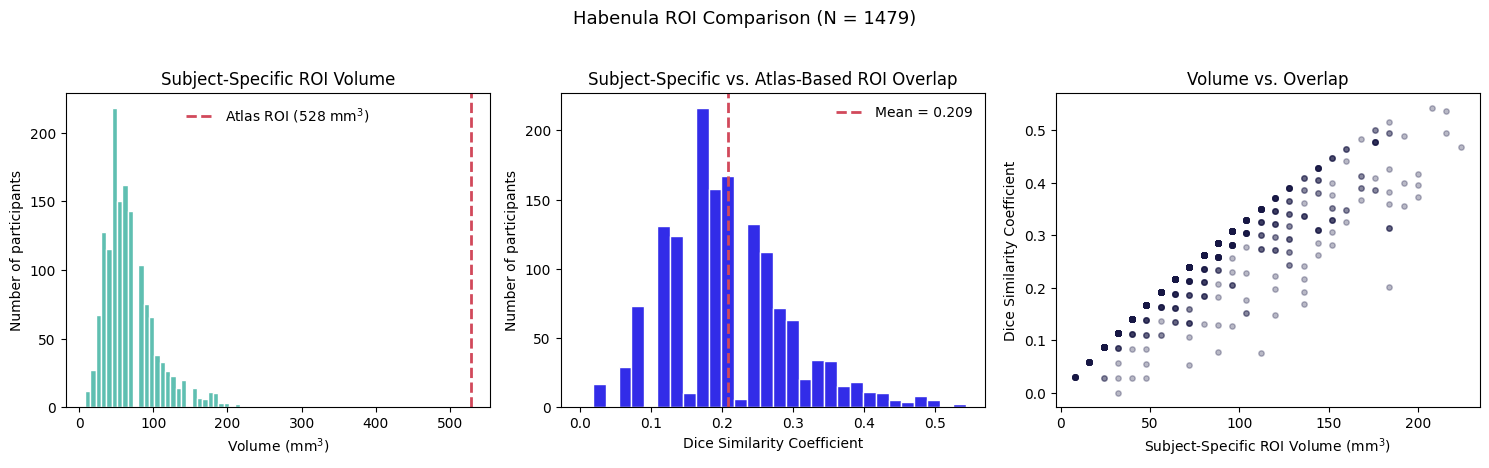

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: subject-specific ROI volume distribution vs. atlas ROI volume ---
axes[0].hist(df_results["subj_volume_mm3"], bins=30, color="#5fbfb1", edgecolor="white")
axes[0].axvline(atlas_volume_mm3, color="#d1495b", linestyle="--", linewidth=2,
                 label=f"Atlas ROI ({atlas_volume_mm3:.0f} mm$^3$)")
axes[0].set_xlabel("Volume (mm$^3$)")
axes[0].set_ylabel("Number of participants")
axes[0].set_title("Subject-Specific ROI Volume")
axes[0].legend(frameon=False)

# --- Panel 2: Dice coefficient distribution ---
axes[1].hist(df_results["dice"], bins=30, color="#322ce8", edgecolor="white")
axes[1].axvline(df_results["dice"].mean(), color="#d1495b", linestyle="--", linewidth=2,
                 label=f"Mean = {df_results['dice'].mean():.3f}")
axes[1].set_xlabel("Dice Similarity Coefficient")
axes[1].set_ylabel("Number of participants")
axes[1].set_title("Subject-Specific vs. Atlas-Based ROI Overlap")
axes[1].legend(frameon=False)

# --- Panel 3: volume vs. Dice relationship ---
axes[2].scatter(df_results["subj_volume_mm3"], df_results["dice"], alpha=0.3, s=15, color="#171744")
axes[2].set_xlabel("Subject-Specific ROI Volume (mm$^3$)")
axes[2].set_ylabel("Dice Similarity Coefficient")
axes[2].set_title("Volume vs. Overlap")

fig.suptitle(f"Habenula ROI Comparison (N = {len(df_results)})", fontsize=13, y=1.03)
fig.tight_layout()

fig_path = op.join(output_dir, "roi_comparison_plots.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()


## 7. Save Results

In [8]:
df_results.to_csv(output_csv, index=False)
print(f"Results saved to: {output_csv}")


Results saved to: ./dset/derivatives/roi-analysis/roi_comparison_summary.csv
